# Notebook 1S v3 — Low-cost, publication-oriented SoilGrids data collection

This notebook replaces Notebook 1S and Notebook 1S v2.

The goal is **not exhaustive SoilGrids extraction**. Exhaustive extraction is expensive and unnecessary for a first publishable methods/resource paper.

Instead, this notebook implements a **pre-specified, balanced, stratified SoilGrids sampling design**:

> fixed number of spatial blocks per taxon × geographically stratified selection × reproducible random seed × cache reuse.

This is much cheaper and more defensible than querying thousands of points unevenly.

## Why this version is more publishable

The earlier output was not publishable because it was imbalanced: Hypericum received many SoilGrids-linked points while Rhodiola received none.

This version makes the sampling strategy explicit and reproducible:

1. **Balanced by taxon**
   - Each target taxon receives approximately the same number of selected spatial blocks.

2. **Stratified by geography**
   - Within each taxon, selected blocks are spread across latitude bands and longitude sectors.

3. **Low-cost by design**
   - Default: 40 spatial blocks per taxon.
   - With six taxa, this is usually ≤240 SoilGrids property calls, often fewer because shared blocks and cached calls are reused.

4. **Publication-grade QC**
   - Writes sampling-design tables.
   - Writes taxon coverage tables.
   - Writes cache-use report.
   - Produces figure panels proving that the design is balanced.

5. **No GPU**
   - SoilGrids extraction is remote API querying plus small pandas operations.
   - CPU runtime is low compared with exhaustive extraction.

## Scientific framing

This notebook supports a publishable claim such as:

> We developed a reproducible low-cost open-data framework for associating medicinal-plant occurrence space with global SoilGrids-derived soil niches.

It does **not** support a causal claim such as:

> Soil pH controls salidroside accumulation.

Causal or concentration-level claims require measured metabolite data and/or field sampling.

## 0. Output policy

Proceed to Notebook 2S only if the final table:

`derived/soilgrids_coverage_by_taxon_v3.tsv`

shows adequate balanced coverage.

Default readiness rule:

- at least **30 selected SoilGrids blocks per taxon**, or
- at least **80 occurrence records covered by selected SoilGrids blocks per taxon**.

For the lowest-cost publishable pilot, 30–40 blocks per taxon is acceptable if the manuscript is framed as a **workflow/resource proof-of-concept**.

For a stronger Q1 submission, increase:

```python
CONFIG["target_soil_blocks_per_taxon"] = 80
```

and rerun using the cache.

In [1]:
# ============================================================
# 0. Imports
# ============================================================

import os
import re
import json
import time
import math
import pathlib
import hashlib
import warnings
import datetime as dt
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 220)

In [2]:
# ============================================================
# 1. Low-cost publication-oriented configuration
# ============================================================

CONFIG = {
    "project_dir": "soilgrids_medicinal_value_dataset_v3_low_cost",

    # Try to reuse previous Notebook 1S outputs/cache if they exist.
    # Add paths in "input_dirs" below.
    "resume_from_existing_outputs": True,
    "input_dirs": [
        ".",
        "/content",
        "/mnt/data",
        "/content/soilgrids_medicinal_value_dataset",
        "/content/soilgrids_medicinal_value_dataset/gbif",
        "/content/soilgrids_medicinal_value_dataset/soilgrids",
        "/content/soilgrids_medicinal_value_dataset/derived",
        "/content/soilgrids_medicinal_value_dataset_v3_low_cost",
    ],

    # GBIF settings.
    # If previous GBIF files exist, they are reused and these limits are ignored.
    "gbif_occurrence_limit_per_taxon": 1000,
    "gbif_occurrence_country": "",  # "KZ" for Kazakhstan-only, empty for global.
    "gbif_liberal_coordinate_uncertainty_m": 10000,
    "gbif_strict_coordinate_uncertainty_m": 1000,
    "gbif_preferred_basis_of_record": ["PRESERVED_SPECIMEN", "MATERIAL_SAMPLE", "LIVING_SPECIMEN"],

    # Spatial blocks.
    # 0.25 degree gives a moderate number of blocks.
    # Use 0.5 if API cost must be even lower.
    "spatial_block_degrees": 0.25,

    # Low-cost balanced sampling design.
    # Main knob controlling API cost.
    # 40 blocks × 6 taxa ≈ up to 240 SoilGrids calls.
    "target_soil_blocks_per_taxon": 40,

    # Additional safety cap for new API calls in a single run.
    # Set None to allow all missing selected blocks to be queried.
    "max_new_soilgrids_points_this_run": None,

    # SoilGrids fast variables.
    # 7 properties × 3 depths × 1 value = 21 variables.
    "soilgrids_base_url": "https://rest.isric.org/soilgrids/v2.0",
    "soilgrids_properties": ["phh2o", "soc", "clay", "sand", "silt", "cec", "nitrogen"],
    "soilgrids_depths": ["0-5cm", "5-15cm", "15-30cm"],
    "soilgrids_values": ["mean"],

    # Disable WRB for low-cost primary run.
    "run_wrb_classification": False,

    # API behavior.
    "request_sleep_seconds": 0.15,
    "request_retries": 5,
    "checkpoint_every_n_points": 20,

    # Readiness gates.
    "min_soil_blocks_per_taxon_for_notebook2": 30,
    "min_occurrences_covered_per_taxon_for_notebook2": 80,

    # Figures.
    "figure_dpi": 300,
    "save_pdf": True,

    "random_seed": 42,
}

TARGET_TAXA = [
    {"taxon_id": "TAX_SEDUM", "scientific_name": "Sedum", "rank": "genus", "family": "Crassulaceae", "priority": "project_core"},
    {"taxon_id": "TAX_RHODIOLA", "scientific_name": "Rhodiola", "rank": "genus", "family": "Crassulaceae", "priority": "project_core"},
    {"taxon_id": "TAX_HYPERICUM", "scientific_name": "Hypericum", "rank": "genus", "family": "Hypericaceae", "priority": "project_core"},
    {"taxon_id": "TAX_ARTEMISIA_ANNUA", "scientific_name": "Artemisia annua", "rank": "species", "family": "Asteraceae", "priority": "positive_control"},
    {"taxon_id": "TAX_GLYCYRRHIZA_GLABRA", "scientific_name": "Glycyrrhiza glabra", "rank": "species", "family": "Fabaceae", "priority": "positive_control"},
    {"taxon_id": "TAX_TAXUS", "scientific_name": "Taxus", "rank": "genus", "family": "Taxaceae", "priority": "positive_control"},
]

TARGET_COMPOUNDS = [
    {"compound_id": "CMP_SALIDROSIDE", "compound_name": "salidroside", "compound_class": "phenolic glycoside", "record_type": "molecule", "relevant_taxa": "Rhodiola"},
    {"compound_id": "CMP_TYROSOL", "compound_name": "tyrosol", "compound_class": "phenolic alcohol", "record_type": "molecule", "relevant_taxa": "Rhodiola"},
    {"compound_id": "CMP_HYPERICIN", "compound_name": "hypericin", "compound_class": "naphthodianthrone", "record_type": "molecule", "relevant_taxa": "Hypericum"},
    {"compound_id": "CMP_ARTEMISININ", "compound_name": "artemisinin", "compound_class": "sesquiterpene lactone", "record_type": "molecule", "relevant_taxa": "Artemisia"},
    {"compound_id": "CMP_GLYCYRRHIZIN", "compound_name": "glycyrrhizin", "compound_class": "triterpenoid saponin", "record_type": "molecule", "relevant_taxa": "Glycyrrhiza"},
    {"compound_id": "CMP_PACLITAXEL", "compound_name": "paclitaxel", "compound_class": "diterpenoid taxane", "record_type": "molecule", "relevant_taxa": "Taxus"},
    {"compound_id": "CMP_TOTAL_FLAVONOIDS", "compound_name": "flavonoids", "compound_class": "flavonoids", "record_type": "compound_class", "relevant_taxa": "broad plants"},
    {"compound_id": "CMP_TOTAL_PHENOLICS", "compound_name": "phenolic compounds", "compound_class": "phenolic compounds", "record_type": "compound_class", "relevant_taxa": "broad plants"},
]

PROJECT = pathlib.Path(CONFIG["project_dir"]).resolve()
DIRS = {
    "metadata": PROJECT / "metadata",
    "gbif": PROJECT / "gbif",
    "soilgrids": PROJECT / "soilgrids",
    "derived": PROJECT / "derived",
    "figures": PROJECT / "figures",
    "logs": PROJECT / "logs",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

RUN_ID = dt.datetime.now(dt.timezone.utc).strftime("%Y%m%dT%H%M%SZ")
CONFIG["run_id"] = RUN_ID
CONFIG["created_utc"] = dt.datetime.now(dt.timezone.utc).isoformat(timespec="seconds")

pd.DataFrame(TARGET_TAXA).to_csv(DIRS["metadata"] / "target_taxa_config.tsv", sep="\t", index=False)
pd.DataFrame(TARGET_COMPOUNDS).to_csv(DIRS["metadata"] / "target_compounds_config.tsv", sep="\t", index=False)

with open(PROJECT / "notebook1S_v3_low_cost_config.json", "w", encoding="utf-8") as f:
    json.dump(CONFIG, f, indent=2, ensure_ascii=False)

PROJECT

PosixPath('/content/soilgrids_medicinal_value_dataset_v3_low_cost')

In [3]:
# ============================================================
# 2. Utilities
# ============================================================

SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "soilgrids-medicinal-low-cost-v3/1.0"})

def utc_now():
    return dt.datetime.now(dt.timezone.utc).isoformat(timespec="seconds")

def safe_name(x: str, max_len: int = 180) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(x)).strip("_")[:max_len]

def write_table(df: pd.DataFrame, path_stem: pathlib.Path):
    path_stem.parent.mkdir(parents=True, exist_ok=True)
    tsv = path_stem.with_suffix(".tsv")
    df.to_csv(tsv, sep="\t", index=False)
    try:
        df.to_parquet(path_stem.with_suffix(".parquet"), index=False)
    except Exception as e:
        print(f"Parquet skipped for {path_stem.name}: {e}")
    return tsv

def save_figure(fig, name: str):
    png = DIRS["figures"] / f"{safe_name(name)}.png"
    fig.savefig(png, dpi=CONFIG["figure_dpi"], bbox_inches="tight")
    if CONFIG["save_pdf"]:
        fig.savefig(DIRS["figures"] / f"{safe_name(name)}.pdf", bbox_inches="tight")
    print("Saved:", png)

def find_existing_file(filename: str):
    candidates = []
    for d in CONFIG["input_dirs"]:
        d = pathlib.Path(d)
        candidates.append(d / filename)
        if d.exists() and d.is_dir():
            candidates.extend(d.rglob(filename))
    existing = sorted(set([p for p in candidates if p.exists() and p.stat().st_size > 0]), key=lambda p: (len(str(p)), str(p)))
    return existing[0] if existing else None

def load_existing_tsv(filename: str) -> pd.DataFrame:
    p = find_existing_file(filename)
    if p is None:
        return pd.DataFrame()
    print(f"Loaded existing {filename} from {p}")
    return pd.read_csv(p, sep="\t", dtype=str, low_memory=False)

def request_get_json(url, params=None, retries=None, sleep=None, timeout=120):
    retries = CONFIG["request_retries"] if retries is None else retries
    sleep = CONFIG["request_sleep_seconds"] if sleep is None else sleep
    last_error = None
    for i in range(retries):
        try:
            r = SESSION.get(url, params=params, timeout=timeout)
            if r.status_code in [429, 500, 502, 503, 504]:
                last_error = f"HTTP {r.status_code}: {r.text[:300]}"
                time.sleep(sleep * (2 ** i))
                continue
            r.raise_for_status()
            time.sleep(sleep)
            return r.json()
        except Exception as e:
            last_error = str(e)
            time.sleep(sleep * (2 ** i))
    raise RuntimeError(f"GET failed: {url} params={params}; last_error={last_error}")

def add_provenance(df, source, query):
    df = df.copy()
    df["source"] = source
    df["query"] = query
    df["retrieved_utc"] = utc_now()
    df["run_id"] = RUN_ID
    return df

# Cache compatibility: reuse cache from current v3 folder and previous v1/v2 folder if present.
def local_cache_file(point_id, suffix="properties_fast"):
    return DIRS["soilgrids"] / "api_cache" / f"{safe_name(point_id)}__{suffix}.json"

def find_cached_json(point_id):
    possible_names = [
        f"{safe_name(point_id)}__properties_fast.json",
        f"{safe_name(point_id)}__properties.json",
    ]
    possible_dirs = [DIRS["soilgrids"] / "api_cache"]
    for d in CONFIG["input_dirs"]:
        d = pathlib.Path(d)
        possible_dirs.append(d / "api_cache")
        possible_dirs.append(d / "soilgrids" / "api_cache")
    for d in possible_dirs:
        for nm in possible_names:
            p = d / nm
            if p.exists() and p.stat().st_size > 0:
                return p
    return None

def has_cached_soil(point_id):
    return find_cached_json(point_id) is not None

def read_cached_soil(point_id):
    p = find_cached_json(point_id)
    if p is None:
        return None
    return json.loads(p.read_text(encoding="utf-8"))

## 1. Load or collect GBIF records

To minimize cost, this notebook first tries to reuse existing GBIF outputs.

If no previous GBIF output exists, it collects a capped number of records per taxon.

In [4]:
# ============================================================
# 3. Load or collect GBIF occurrence records
# ============================================================

GBIF_OCCURRENCE_SEARCH = "https://api.gbif.org/v1/occurrence/search"
GBIF_SPECIES_MATCH = "https://api.gbif.org/v1/species/match"

def gbif_match_taxon(name):
    return request_get_json(GBIF_SPECIES_MATCH, params={"name": name})

def gbif_occurrences(scientific_name: str, limit: int = 1000, country: str = "") -> pd.DataFrame:
    match = gbif_match_taxon(scientific_name)
    taxon_key = match.get("usageKey") or match.get("acceptedUsageKey")
    if not taxon_key:
        return pd.DataFrame([{"scientific_name_query": scientific_name, "gbif_error": match.get("error", "no taxon key")}])

    rows = []
    page_limit = min(300, limit)
    offset = 0

    while offset < limit:
        params = {"taxonKey": taxon_key, "hasCoordinate": "true", "limit": page_limit, "offset": offset}
        if country:
            params["country"] = country

        data = request_get_json(GBIF_OCCURRENCE_SEARCH, params=params, timeout=120)

        for rec in data.get("results", []):
            rows.append({
                "gbif_key": rec.get("key"),
                "taxon_key": taxon_key,
                "scientific_name_query": scientific_name,
                "scientific_name": rec.get("scientificName"),
                "accepted_scientific_name": rec.get("acceptedScientificName"),
                "country": rec.get("country"),
                "country_code": rec.get("countryCode"),
                "decimal_latitude": rec.get("decimalLatitude"),
                "decimal_longitude": rec.get("decimalLongitude"),
                "coordinate_uncertainty_m": rec.get("coordinateUncertaintyInMeters"),
                "event_date": rec.get("eventDate"),
                "basis_of_record": rec.get("basisOfRecord"),
                "institution_code": rec.get("institutionCode"),
                "dataset_key": rec.get("datasetKey"),
                "has_geospatial_issue": rec.get("hasGeospatialIssues"),
                "last_interpreted": rec.get("lastInterpreted"),
                "gbif_match_taxon_key": taxon_key,
                "gbif_match_status": match.get("matchType"),
                "gbif_match_confidence": match.get("confidence"),
            })

        if data.get("endOfRecords", False):
            break
        offset += page_limit

    df = pd.DataFrame(rows)
    if not df.empty:
        df = add_provenance(df, "GBIF occurrence API", f"taxonKey={taxon_key}; country={country or 'global'}")
    return df

existing_gbif = load_existing_tsv("gbif_occurrence_manifest.tsv")

if CONFIG["resume_from_existing_outputs"] and not existing_gbif.empty:
    gbif_df = existing_gbif.copy()
else:
    tables = []
    for tax in tqdm(TARGET_TAXA, desc="GBIF taxa"):
        df = gbif_occurrences(
            tax["scientific_name"],
            limit=CONFIG["gbif_occurrence_limit_per_taxon"],
            country=CONFIG["gbif_occurrence_country"],
        )
        if not df.empty:
            df["taxon_id"] = tax["taxon_id"]
            df["input_taxon"] = tax["scientific_name"]
            df["family"] = tax["family"]
            df["rank"] = tax["rank"]
            df["priority"] = tax["priority"]
            tables.append(df)
    gbif_df = pd.concat(tables, ignore_index=True) if tables else pd.DataFrame()

if not gbif_df.empty and "gbif_key" in gbif_df.columns:
    gbif_df = gbif_df.drop_duplicates(subset=["gbif_key"])

write_table(gbif_df, DIRS["gbif"] / "gbif_occurrence_manifest")

print("GBIF rows:", len(gbif_df))
gbif_df.head()

GBIF taxa:   0%|          | 0/6 [00:00<?, ?it/s]

GBIF rows: 7200


,gbif_key,taxon_key,scientific_name_query,scientific_name,accepted_scientific_name,country,country_code,decimal_latitude,decimal_longitude,coordinate_uncertainty_m,event_date,basis_of_record,institution_code,dataset_key,has_geospatial_issue,last_interpreted,gbif_match_taxon_key,gbif_match_status,gbif_match_confidence,source,query,retrieved_utc,run_id,taxon_id,input_taxon,family,rank,priority
0,5938030633,5361975,Sedum,Sedum hispanicum L.,Sedum hispanicum L.,Italy,IT,46.216905,13.222121,26.0,2026-01-03T13:21:21,HUMAN_OBSERVATION,iNaturalist,50c9509d-22c7-4a22-a47d-8c48425ef4a7,None,2026-05-08T22:15:06.327+00:00,5361975,HIGHERRANK,94,GBIF occurrence API,taxonKey=5361975; country=global,2026-05-15T04:47:58+00:00,20260515T044756Z,TAX_SEDUM,Sedum,Crassulaceae,genus,project_core
1,5938036248,5361975,Sedum,Sedum album L.,Sedum album L.,France,FR,43.283052,5.370825,NaN,2026-01-04T17:49,HUMAN_OBSERVATION,iNaturalist,50c9509d-22c7-4a22-a47d-8c48425ef4a7,None,2026-05-08T22:06:16.452+00:00,5361975,HIGHERRANK,94,GBIF occurrence API,taxonKey=5361975; country=global,2026-05-15T04:47:58+00:00,20260515T044756Z,TAX_SEDUM,Sedum,Crassulaceae,genus,project_core
2,5938040436,5361975,Sedum,Sedum dasyphyllum L.,Sedum dasyphyllum L.,France,FR,43.284080,5.369642,NaN,2026-01-04T17:57,HUMAN_OBSERVATION,iNaturalist,50c9509d-22c7-4a22-a47d-8c48425ef4a7,None,2026-05-08T21:54:48.819+00:00,5361975,HIGHERRANK,94,GBIF occurrence API,taxonKey=5361975; country=global,2026-05-15T04:47:58+00:00,20260515T044756Z,TAX_SEDUM,Sedum,Crassulaceae,genus,project_core
3,5938047369,5361975,Sedum,Sedum sexangulare L.,Sedum sexangulare L.,Hungary,HU,47.902580,19.758109,4.0,2026-01-01T14:27:50,HUMAN_OBSERVATION,iNaturalist,50c9509d-22c7-4a22-a47d-8c48425ef4a7,None,2026-05-08T22:04:41.071+00:00,5361975,HIGHERRANK,94,GBIF occurrence API,taxonKey=5361975; country=global,2026-05-15T04:47:58+00:00,20260515T044756Z,TAX_SEDUM,Sedum,Crassulaceae,genus,project_core
4,5938050053,5361975,Sedum,Sedum dasyphyllum L.,Sedum dasyphyllum L.,France,FR,43.283152,5.370802,NaN,2026-01-04T17:48,HUMAN_OBSERVATION,iNaturalist,50c9509d-22c7-4a22-a47d-8c48425ef4a7,None,2026-05-08T21:53:43.866+00:00,5361975,HIGHERRANK,94,GBIF occurrence API,taxonKey=5361975; country=global,2026-05-15T04:47:58+00:00,20260515T044756Z,TAX_SEDUM,Sedum,Crassulaceae,genus,project_core


In [5]:
# ============================================================
# 4. Coordinate QC and spatial blocks
# ============================================================

def filter_gbif(df, uncertainty_threshold_m, specimen_only=False):
    if df.empty:
        return pd.DataFrame()

    out = df.copy()
    out["decimal_latitude"] = pd.to_numeric(out["decimal_latitude"], errors="coerce")
    out["decimal_longitude"] = pd.to_numeric(out["decimal_longitude"], errors="coerce")
    out["coordinate_uncertainty_m"] = pd.to_numeric(out["coordinate_uncertainty_m"], errors="coerce")

    keep = (
        out["decimal_latitude"].between(-90, 90) &
        out["decimal_longitude"].between(-180, 180) &
        (~out["has_geospatial_issue"].astype(str).str.lower().isin(["true", "1", "yes"])) &
        (out["coordinate_uncertainty_m"].isna() | (out["coordinate_uncertainty_m"] <= uncertainty_threshold_m))
    )

    if specimen_only:
        keep = keep & out["basis_of_record"].isin(CONFIG["gbif_preferred_basis_of_record"])

    out = out[keep].copy()

    block = CONFIG["spatial_block_degrees"]
    out["spatial_block_lat"] = np.floor(out["decimal_latitude"] / block).astype("Int64")
    out["spatial_block_lon"] = np.floor(out["decimal_longitude"] / block).astype("Int64")
    out["spatial_block_id"] = out["spatial_block_lat"].astype(str) + "_" + out["spatial_block_lon"].astype(str)
    out["block_centroid_latitude"] = (out["spatial_block_lat"].astype(float) + 0.5) * block
    out["block_centroid_longitude"] = (out["spatial_block_lon"].astype(float) + 0.5) * block

    out["abs_latitude"] = out["decimal_latitude"].abs()
    out["latitudinal_band"] = pd.cut(
        out["decimal_latitude"],
        bins=[-90, -60, -35, -23.5, 0, 23.5, 35, 60, 90],
        labels=["antarctic_subpolar", "south_temperate", "south_subtropical", "south_tropical",
                "north_tropical", "north_subtropical", "north_temperate", "arctic_subpolar"],
        include_lowest=True
    ).astype(str)
    out["longitude_sector_30deg"] = np.floor((out["decimal_longitude"] + 180) / 30).astype("Int64").astype(str)
    out["geo_stratum"] = out["latitudinal_band"].astype(str) + "__lonsec_" + out["longitude_sector_30deg"].astype(str)

    return out

gbif_liberal_df = filter_gbif(gbif_df, CONFIG["gbif_liberal_coordinate_uncertainty_m"], specimen_only=False)
gbif_strict_df = filter_gbif(gbif_df, CONFIG["gbif_strict_coordinate_uncertainty_m"], specimen_only=False)
gbif_strict_specimen_df = filter_gbif(gbif_df, CONFIG["gbif_strict_coordinate_uncertainty_m"], specimen_only=True)

write_table(gbif_liberal_df, DIRS["gbif"] / "gbif_occurrence_liberal_filtered")
write_table(gbif_strict_df, DIRS["gbif"] / "gbif_occurrence_strict_filtered")
write_table(gbif_strict_specimen_df, DIRS["gbif"] / "gbif_occurrence_strict_specimen")

gbif_qc_df = pd.DataFrame([
    {"metric": "raw_records", "value": len(gbif_df)},
    {"metric": "liberal_filtered_records", "value": len(gbif_liberal_df)},
    {"metric": "strict_filtered_records", "value": len(gbif_strict_df)},
    {"metric": "strict_specimen_records", "value": len(gbif_strict_specimen_df)},
    {"metric": "liberal_spatial_blocks", "value": gbif_liberal_df["spatial_block_id"].nunique()},
])
write_table(gbif_qc_df, DIRS["gbif"] / "gbif_occurrence_qc_summary")

display(gbif_qc_df)

,metric,value
0,raw_records,7200
1,liberal_filtered_records,7032
2,strict_filtered_records,6115
3,strict_specimen_records,132
4,liberal_spatial_blocks,2523


## 2. Low-cost balanced SoilGrids sampling design

The key idea:

1. Create taxon × spatial-block candidates.
2. Stratify by latitude band and longitude sector.
3. Select a fixed quota of blocks per taxon.
4. Query each unique spatial block only once.
5. Reuse existing cached SoilGrids responses.

This gives a balanced, publishable, reproducible sampling design at low API cost.

In [6]:
# ============================================================
# 5. Build low-cost stratified balanced sampling design
# ============================================================

if gbif_liberal_df.empty:
    raise RuntimeError("No liberal GBIF records available.")

rng = np.random.default_rng(CONFIG["random_seed"])

# One row per taxon × spatial block.
taxon_block_df = (
    gbif_liberal_df
    .groupby(["taxon_id", "input_taxon", "family", "rank", "priority", "spatial_block_id", "geo_stratum"], as_index=False)
    .agg(
        n_occurrences_in_taxon_block=("gbif_key", "count"),
        decimal_latitude=("block_centroid_latitude", "first"),
        decimal_longitude=("block_centroid_longitude", "first"),
        mean_abs_latitude=("abs_latitude", "mean"),
    )
)

taxon_block_df["point_id"] = "SBLOCK_" + taxon_block_df["spatial_block_id"].astype(str)
taxon_block_df["has_cached_soil"] = taxon_block_df["point_id"].apply(has_cached_soil)
taxon_block_df["random_tiebreaker"] = rng.random(len(taxon_block_df))

selected_rows = []
quota = int(CONFIG["target_soil_blocks_per_taxon"])

for taxon_id, sub in taxon_block_df.groupby("taxon_id"):
    # Step 1: select one best block per geo_stratum to maximize spatial representativeness.
    stratum_best = (
        sub.sort_values(["has_cached_soil", "n_occurrences_in_taxon_block", "random_tiebreaker"],
                        ascending=[False, False, True])
        .groupby("geo_stratum", as_index=False)
        .head(1)
        .copy()
    )

    # Step 2: if quota not filled, add high-occurrence blocks.
    remaining = sub[~sub["spatial_block_id"].isin(stratum_best["spatial_block_id"])].copy()
    remaining = remaining.sort_values(
        ["has_cached_soil", "n_occurrences_in_taxon_block", "random_tiebreaker"],
        ascending=[False, False, True]
    )

    chosen = pd.concat([stratum_best, remaining], ignore_index=True).head(quota)
    selected_rows.append(chosen)

selected_taxon_block_df = pd.concat(selected_rows, ignore_index=True) if selected_rows else pd.DataFrame()

# Unique SoilGrids API points. One spatial block may support multiple taxa.
point_df = (
    selected_taxon_block_df
    .sort_values(["has_cached_soil", "n_occurrences_in_taxon_block"], ascending=[False, False])
    .drop_duplicates(subset=["spatial_block_id"])
    .copy()
)

point_df["point_id"] = "SBLOCK_" + point_df["spatial_block_id"].astype(str)
point_df["query_level"] = "low_cost_stratified_taxon_spatial_block"
point_df["already_cached"] = point_df["point_id"].apply(has_cached_soil)

new_point_df = point_df[~point_df["already_cached"]].copy()
if CONFIG["max_new_soilgrids_points_this_run"] is not None:
    new_point_df = new_point_df.head(int(CONFIG["max_new_soilgrids_points_this_run"])).copy()

cached_selected_df = point_df[point_df["already_cached"]].copy()
query_point_df = pd.concat([cached_selected_df, new_point_df], ignore_index=True).drop_duplicates(subset=["point_id"])

write_table(taxon_block_df, DIRS["soilgrids"] / "soilgrids_taxon_block_candidates_v3")
write_table(selected_taxon_block_df, DIRS["soilgrids"] / "soilgrids_selected_taxon_blocks_stratified_v3")
write_table(point_df, DIRS["soilgrids"] / "soilgrids_query_points_all_selected_v3")
write_table(query_point_df, DIRS["soilgrids"] / "soilgrids_query_points")

sampling_plan_df = (
    selected_taxon_block_df
    .groupby(["taxon_id", "input_taxon"], as_index=False)
    .agg(
        selected_taxon_blocks=("spatial_block_id", "nunique"),
        selected_geo_strata=("geo_stratum", "nunique"),
        selected_cached_taxon_blocks=("has_cached_soil", "sum"),
        selected_occurrences_represented=("n_occurrences_in_taxon_block", "sum"),
    )
)

sampling_plan_df["target_blocks_per_taxon"] = quota
sampling_plan_df["selected_cached_taxon_blocks"] = sampling_plan_df["selected_cached_taxon_blocks"].astype(int)

write_table(sampling_plan_df, DIRS["soilgrids"] / "soilgrids_low_cost_sampling_plan_by_taxon_v3")

print("Taxon-block candidates:", len(taxon_block_df))
print("Selected taxon-block rows:", len(selected_taxon_block_df))
print("Unique SoilGrids points selected:", len(point_df))
print("Already cached selected points:", int(point_df["already_cached"].sum()))
print("New SoilGrids API calls required this run:", len(new_point_df))
print("Total points loaded/queried this run:", len(query_point_df))
display(sampling_plan_df)
display(query_point_df.head())

Taxon-block candidates: 2922
Selected taxon-block rows: 240
Unique SoilGrids points selected: 222
Already cached selected points: 0
New SoilGrids API calls required this run: 222
Total points loaded/queried this run: 222


,taxon_id,input_taxon,selected_taxon_blocks,selected_geo_strata,selected_cached_taxon_blocks,selected_occurrences_represented,target_blocks_per_taxon
0,TAX_ARTEMISIA_ANNUA,Artemisia annua,40,19,0,488,40
1,TAX_GLYCYRRHIZA_GLABRA,Glycyrrhiza glabra,40,7,0,453,40
2,TAX_HYPERICUM,Hypericum,40,29,0,294,40
3,TAX_RHODIOLA,Rhodiola,40,18,0,416,40
4,TAX_SEDUM,Sedum,40,19,0,390,40
5,TAX_TAXUS,Taxus,40,11,0,536,40


,taxon_id,input_taxon,family,rank,priority,spatial_block_id,geo_stratum,n_occurrences_in_taxon_block,decimal_latitude,decimal_longitude,mean_abs_latitude,point_id,has_cached_soil,random_tiebreaker,query_level,already_cached
0,TAX_ARTEMISIA_ANNUA,Artemisia annua,Asteraceae,species,positive_control,204_17,north_temperate__lonsec_6,100,51.125,4.375,51.232414,SBLOCK_204_17,False,0.238553,low_cost_stratified_taxon_spatial_block,False
1,TAX_SEDUM,Sedum,Crassulaceae,genus,project_core,205_14,north_temperate__lonsec_6,57,51.375,3.625,51.443860,SBLOCK_205_14,False,0.047250,low_cost_stratified_taxon_spatial_block,False
2,TAX_GLYCYRRHIZA_GLABRA,Glycyrrhiza glabra,Fabaceae,species,positive_control,180_148,north_temperate__lonsec_7,40,45.125,37.125,45.052463,SBLOCK_180_148,False,0.590195,low_cost_stratified_taxon_spatial_block,False
3,TAX_HYPERICUM,Hypericum,Hypericaceae,genus,project_core,-141_598,south_temperate__lonsec_10,40,-35.125,149.625,35.158250,SBLOCK_-141_598,False,0.860630,low_cost_stratified_taxon_spatial_block,False
4,TAX_ARTEMISIA_ANNUA,Artemisia annua,Asteraceae,species,positive_control,158_267,north_temperate__lonsec_8,37,39.625,66.875,39.628622,SBLOCK_158_267,False,0.856614,low_cost_stratified_taxon_spatial_block,False


In [7]:
# ============================================================
# 6. Pre-query coverage estimate
# ============================================================

selected_blocks = set(point_df["spatial_block_id"].astype(str))
gbif_liberal_df["selected_for_soil_v3"] = gbif_liberal_df["spatial_block_id"].astype(str).isin(selected_blocks)

pre_coverage_df = (
    gbif_liberal_df
    .groupby(["taxon_id", "input_taxon"], as_index=False)
    .agg(
        total_occurrences=("gbif_key", "count"),
        total_spatial_blocks=("spatial_block_id", "nunique"),
        estimated_occurrences_covered=("selected_for_soil_v3", "sum"),
    )
)

pre_blocks = (
    gbif_liberal_df[gbif_liberal_df["selected_for_soil_v3"]]
    .groupby(["taxon_id", "input_taxon"])["spatial_block_id"]
    .nunique()
    .reset_index(name="estimated_spatial_blocks_covered")
)

pre_coverage_df = pre_coverage_df.merge(pre_blocks, on=["taxon_id", "input_taxon"], how="left")
pre_coverage_df["estimated_spatial_blocks_covered"] = pre_coverage_df["estimated_spatial_blocks_covered"].fillna(0).astype(int)
pre_coverage_df["estimated_pct_occurrences_covered"] = (
    100 * pre_coverage_df["estimated_occurrences_covered"] / pre_coverage_df["total_occurrences"]
).round(2)

pre_coverage_df["estimated_ready_for_notebook2"] = (
    (pre_coverage_df["estimated_spatial_blocks_covered"] >= CONFIG["min_soil_blocks_per_taxon_for_notebook2"]) |
    (pre_coverage_df["estimated_occurrences_covered"] >= CONFIG["min_occurrences_covered_per_taxon_for_notebook2"])
)

write_table(pre_coverage_df, DIRS["soilgrids"] / "soilgrids_pre_query_coverage_estimate_v3")
display(pre_coverage_df)

,taxon_id,input_taxon,total_occurrences,total_spatial_blocks,estimated_occurrences_covered,estimated_spatial_blocks_covered,estimated_pct_occurrences_covered,estimated_ready_for_notebook2
0,TAX_ARTEMISIA_ANNUA,Artemisia annua,1184,465,512,49,43.24,True
1,TAX_GLYCYRRHIZA_GLABRA,Glycyrrhiza glabra,1185,481,456,43,38.48,True
2,TAX_HYPERICUM,Hypericum,1157,594,357,72,30.86,True
3,TAX_RHODIOLA,Rhodiola,1160,464,416,40,35.86,True
4,TAX_SEDUM,Sedum,1163,518,438,63,37.66,True
5,TAX_TAXUS,Taxus,1183,398,584,54,49.37,True


In [8]:
# ============================================================
# 7. SoilGrids query and parser functions
# ============================================================

SOILGRIDS_BASE = CONFIG["soilgrids_base_url"]

cache_dir = DIRS["soilgrids"] / "api_cache"
cache_dir.mkdir(parents=True, exist_ok=True)
checkpoint_dir = DIRS["soilgrids"] / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

def local_cache_file(point_id, suffix="properties_fast"):
    return cache_dir / f"{safe_name(point_id)}__{suffix}.json"

def soilgrids_query_point_fast(lon, lat):
    params = [("lon", float(lon)), ("lat", float(lat))]
    for p in CONFIG["soilgrids_properties"]:
        params.append(("property", p))
    for d in CONFIG["soilgrids_depths"]:
        params.append(("depth", d))
    for v in CONFIG["soilgrids_values"]:
        params.append(("value", v))
    return request_get_json(f"{SOILGRIDS_BASE}/properties/query", params=params, timeout=120)

def parse_soilgrids_response(js, point_id, lon, lat):
    rows = []
    layers = js.get("properties", {}).get("layers", [])
    for layer in layers:
        prop = layer.get("name")
        unit = layer.get("unit_measure", {}) or {}
        d_factor = unit.get("d_factor", 1) or 1
        mapped_units = unit.get("mapped_units", "")
        target_units = unit.get("target_units", "")

        for depth in layer.get("depths", []):
            depth_label = depth.get("label")
            values = depth.get("values", {}) or {}

            for value_name, raw_value in values.items():
                try:
                    scaled_value = float(raw_value) / float(d_factor) if raw_value is not None else np.nan
                except Exception:
                    scaled_value = np.nan

                rows.append({
                    "point_id": point_id,
                    "decimal_longitude": lon,
                    "decimal_latitude": lat,
                    "soil_property": prop,
                    "depth_label": depth_label,
                    "value_type": value_name,
                    "raw_value": raw_value,
                    "d_factor": d_factor,
                    "scaled_value": scaled_value,
                    "mapped_units": mapped_units,
                    "target_units": target_units,
                })
    return rows

## 3. Run the low-cost SoilGrids query

This is the only remote-query cell. It is capped by the sampling design.

With the default settings, it should usually require only ~200–240 calls, and fewer if cache exists.

In [9]:
# ============================================================
# 8. Low-cost balanced SoilGrids query with cache reuse
# ============================================================

soil_rows = []
error_rows = []

print("Unique selected SoilGrids points:", len(point_df))
print("Points loaded/queried this run:", len(query_point_df))
print("New API calls needed:", int((~query_point_df["point_id"].apply(has_cached_soil)).sum()))
print("Properties:", CONFIG["soilgrids_properties"])
print("Depths:", CONFIG["soilgrids_depths"])
print("Values:", CONFIG["soilgrids_values"])

for i, (_, p) in enumerate(tqdm(query_point_df.iterrows(), total=len(query_point_df), desc="SoilGrids low-cost balanced points")):
    pid = p["point_id"]
    lon = float(p["decimal_longitude"])
    lat = float(p["decimal_latitude"])

    try:
        js = read_cached_soil(pid)
        if js is None:
            js = soilgrids_query_point_fast(lon, lat)
            local_cache_file(pid, "properties_fast").write_text(json.dumps(js, indent=2), encoding="utf-8")

        soil_rows.extend(parse_soilgrids_response(js, pid, lon, lat))

    except Exception as e:
        error_rows.append({
            "point_id": pid,
            "error_type": "properties_query",
            "error": str(e),
            "lon": lon,
            "lat": lat,
        })

    if (i + 1) % CONFIG["checkpoint_every_n_points"] == 0:
        pd.DataFrame(soil_rows).to_csv(checkpoint_dir / "soilgrids_point_features_long_checkpoint_v3.tsv", sep="\t", index=False)
        pd.DataFrame(error_rows).to_csv(checkpoint_dir / "soilgrids_query_errors_checkpoint_v3.tsv", sep="\t", index=False)
        print(f"Checkpoint {i+1}: soil rows={len(soil_rows)}, errors={len(error_rows)}")

soilgrids_long_df = pd.DataFrame(soil_rows)
if not soilgrids_long_df.empty:
    soilgrids_long_df = soilgrids_long_df.merge(
        query_point_df[["point_id", "spatial_block_id", "query_level"]],
        on="point_id",
        how="left"
    )
    soilgrids_long_df["source"] = "SoilGrids REST API"
    soilgrids_long_df["query"] = "/properties/query_low_cost_stratified"
    soilgrids_long_df["retrieved_utc"] = utc_now()
    soilgrids_long_df["run_id"] = RUN_ID

error_df = pd.DataFrame(error_rows)
if not error_df.empty:
    error_df["source"] = "SoilGrids REST API"
    error_df["retrieved_utc"] = utc_now()
    error_df["run_id"] = RUN_ID

write_table(soilgrids_long_df, DIRS["soilgrids"] / "soilgrids_point_features_long")
write_table(error_df, DIRS["soilgrids"] / "soilgrids_query_errors")

print("SoilGrids long rows:", len(soilgrids_long_df))
print("Unique points with soil rows:", soilgrids_long_df["point_id"].nunique() if not soilgrids_long_df.empty else 0)
print("Errors:", len(error_df))
display(soilgrids_long_df.head())
display(error_df.head())

Unique selected SoilGrids points: 222
Points loaded/queried this run: 222
New API calls needed: 222
Properties: ['phh2o', 'soc', 'clay', 'sand', 'silt', 'cec', 'nitrogen']
Depths: ['0-5cm', '5-15cm', '15-30cm']
Values: ['mean']


SoilGrids low-cost balanced points:   0%|          | 0/222 [00:00<?, ?it/s]

Checkpoint 20: soil rows=420, errors=0
Checkpoint 40: soil rows=840, errors=0
Checkpoint 60: soil rows=1197, errors=3
Checkpoint 80: soil rows=1617, errors=3
Checkpoint 100: soil rows=2037, errors=3
Checkpoint 120: soil rows=2457, errors=3
Checkpoint 140: soil rows=2877, errors=3
Checkpoint 160: soil rows=3297, errors=3
Checkpoint 180: soil rows=3717, errors=3
Checkpoint 200: soil rows=4137, errors=3
Checkpoint 220: soil rows=4557, errors=3
SoilGrids long rows: 4599
Unique points with soil rows: 219
Errors: 3


,point_id,decimal_longitude,decimal_latitude,soil_property,depth_label,value_type,raw_value,d_factor,scaled_value,mapped_units,target_units,spatial_block_id,query_level,source,query,retrieved_utc,run_id
0,SBLOCK_204_17,4.375,51.125,cec,0-5cm,mean,NaN,10,NaN,mmol(c)/kg,cmol(c)/kg,204_17,low_cost_stratified_taxon_spatial_block,SoilGrids REST API,/properties/query_low_cost_stratified,2026-05-15T05:01:35+00:00,20260515T044756Z
1,SBLOCK_204_17,4.375,51.125,cec,5-15cm,mean,NaN,10,NaN,mmol(c)/kg,cmol(c)/kg,204_17,low_cost_stratified_taxon_spatial_block,SoilGrids REST API,/properties/query_low_cost_stratified,2026-05-15T05:01:35+00:00,20260515T044756Z
2,SBLOCK_204_17,4.375,51.125,cec,15-30cm,mean,NaN,10,NaN,mmol(c)/kg,cmol(c)/kg,204_17,low_cost_stratified_taxon_spatial_block,SoilGrids REST API,/properties/query_low_cost_stratified,2026-05-15T05:01:35+00:00,20260515T044756Z
3,SBLOCK_204_17,4.375,51.125,clay,0-5cm,mean,NaN,10,NaN,g/kg,%,204_17,low_cost_stratified_taxon_spatial_block,SoilGrids REST API,/properties/query_low_cost_stratified,2026-05-15T05:01:35+00:00,20260515T044756Z
4,SBLOCK_204_17,4.375,51.125,clay,5-15cm,mean,NaN,10,NaN,g/kg,%,204_17,low_cost_stratified_taxon_spatial_block,SoilGrids REST API,/properties/query_low_cost_stratified,2026-05-15T05:01:35+00:00,20260515T044756Z


,point_id,error_type,error,lon,lat,source,retrieved_utc,run_id
0,SBLOCK_208_23,properties_query,GET failed: https://rest.isric.org/soilgrids/v...,5.875,52.125,SoilGrids REST API,2026-05-15T05:01:35+00:00,20260515T044756Z
1,SBLOCK_-139_-234,properties_query,GET failed: https://rest.isric.org/soilgrids/v...,-58.375,-34.625,SoilGrids REST API,2026-05-15T05:01:35+00:00,20260515T044756Z
2,SBLOCK_149_-25,properties_query,GET failed: https://rest.isric.org/soilgrids/v...,-6.125,37.375,SoilGrids REST API,2026-05-15T05:01:35+00:00,20260515T044756Z


In [10]:
# ============================================================
# 9. Build wide SoilGrids feature matrix
# ============================================================

if soilgrids_long_df.empty:
    soilgrids_wide_df = pd.DataFrame()
else:
    soilgrids_long_df["feature_name"] = (
        "soil_"
        + soilgrids_long_df["soil_property"].astype(str)
        + "__"
        + soilgrids_long_df["depth_label"].astype(str).str.replace("-", "_", regex=False)
        + "__"
        + soilgrids_long_df["value_type"].astype(str)
    )

    soilgrids_wide_df = (
        soilgrids_long_df
        .pivot_table(
            index=["point_id", "spatial_block_id", "decimal_longitude", "decimal_latitude"],
            columns="feature_name",
            values="scaled_value",
            aggfunc="first"
        )
        .reset_index()
    )
    soilgrids_wide_df.columns.name = None

write_table(soilgrids_wide_df, DIRS["soilgrids"] / "soilgrids_point_features_wide")

print("Wide SoilGrids table:", soilgrids_wide_df.shape)
soilgrids_wide_df.head()

Wide SoilGrids table: (152, 25)


,point_id,spatial_block_id,decimal_longitude,decimal_latitude,soil_cec__0_5cm__mean,soil_cec__15_30cm__mean,soil_cec__5_15cm__mean,soil_clay__0_5cm__mean,soil_clay__15_30cm__mean,soil_clay__5_15cm__mean,soil_nitrogen__0_5cm__mean,soil_nitrogen__15_30cm__mean,soil_nitrogen__5_15cm__mean,soil_phh2o__0_5cm__mean,soil_phh2o__15_30cm__mean,soil_phh2o__5_15cm__mean,soil_sand__0_5cm__mean,soil_sand__15_30cm__mean,soil_sand__5_15cm__mean,soil_silt__0_5cm__mean,soil_silt__15_30cm__mean,soil_silt__5_15cm__mean,soil_soc__0_5cm__mean,soil_soc__15_30cm__mean,soil_soc__5_15cm__mean
0,SBLOCK_-104_113,-104_113,28.375,-25.875,20.0,19.2,20.3,19.5,20.9,19.3,1.29,0.83,0.98,5.8,5.8,5.8,71.2,70.0,71.6,9.3,9.1,9.2,15.8,16.0,11.9
1,SBLOCK_-118_-202,-118_-202,-50.375,-29.375,26.9,19.8,23.0,48.1,48.5,48.1,4.33,3.03,3.59,5.0,5.0,5.0,18.0,18.2,18.0,33.9,33.3,34.0,76.8,73.7,46.2
2,SBLOCK_-120_122,-120_122,30.625,-29.875,17.4,15.1,15.4,22.5,29.1,22.8,2.58,1.29,1.49,5.8,5.8,5.8,51.1,45.9,50.6,26.4,25.0,26.6,33.7,17.6,22.0
3,SBLOCK_-126_602,-126_602,150.625,-31.375,23.1,23.1,23.5,26.5,36.3,25.2,2.47,0.97,1.55,6.7,6.9,6.8,49.9,42.1,50.9,23.6,21.6,23.9,24.2,8.8,18.2
4,SBLOCK_-127_602,-127_602,150.625,-31.625,24.4,24.2,23.7,35.0,37.2,30.6,2.50,1.01,2.03,7.1,7.3,7.2,42.8,41.9,47.1,22.2,20.9,22.3,30.6,10.5,20.3


In [11]:
# ============================================================
# 10. Join selected SoilGrids features back to selected occurrence rows
# ============================================================

# For a low-cost publishable design, keep only occurrence records located in selected blocks.
# This prevents false impression that all GBIF occurrences were soil-extracted.
selected_occ_df = gbif_liberal_df[gbif_liberal_df["spatial_block_id"].astype(str).isin(set(soilgrids_wide_df["spatial_block_id"].astype(str)))].copy()

occ_soil_df = selected_occ_df.merge(
    soilgrids_wide_df.drop(columns=["decimal_longitude", "decimal_latitude"], errors="ignore"),
    on="spatial_block_id",
    how="left"
)

soil_feature_cols = [c for c in occ_soil_df.columns if c.startswith("soil_")]

if soil_feature_cols:
    occ_soil_df["has_any_soil"] = (
        occ_soil_df[soil_feature_cols]
        .apply(lambda row: pd.to_numeric(row, errors="coerce").notna().any(), axis=1)
    )
else:
    occ_soil_df["has_any_soil"] = False

# Also write full GBIF table with selected-block flag for transparency.
gbif_liberal_df["in_low_cost_soilgrids_sample"] = gbif_liberal_df["spatial_block_id"].astype(str).isin(set(soilgrids_wide_df["spatial_block_id"].astype(str)))

write_table(occ_soil_df, DIRS["derived"] / "occurrence_soilgrids_features")
write_table(gbif_liberal_df, DIRS["derived"] / "gbif_liberal_with_soil_sample_flag_v3")

print("Selected occurrence-soil table:", occ_soil_df.shape)
print("Soil features:", len(soil_feature_cols))
print("Occurrences with soil:", int(occ_soil_df["has_any_soil"].sum()))
occ_soil_df.head()

Selected occurrence-soil table: (1815, 61)
Soil features: 21
Occurrences with soil: 1815


,gbif_key,taxon_key,scientific_name_query,scientific_name,accepted_scientific_name,country,country_code,decimal_latitude,decimal_longitude,coordinate_uncertainty_m,event_date,basis_of_record,institution_code,dataset_key,has_geospatial_issue,last_interpreted,gbif_match_taxon_key,gbif_match_status,gbif_match_confidence,source,query,retrieved_utc,run_id,taxon_id,input_taxon,family,rank,priority,spatial_block_lat,spatial_block_lon,spatial_block_id,block_centroid_latitude,block_centroid_longitude,abs_latitude,latitudinal_band,longitude_sector_30deg,geo_stratum,selected_for_soil_v3,point_id,soil_cec__0_5cm__mean,soil_cec__15_30cm__mean,soil_cec__5_15cm__mean,soil_clay__0_5cm__mean,soil_clay__15_30cm__mean,soil_clay__5_15cm__mean,soil_nitrogen__0_5cm__mean,soil_nitrogen__15_30cm__mean,soil_nitrogen__5_15cm__mean,soil_phh2o__0_5cm__mean,soil_phh2o__15_30cm__mean,soil_phh2o__5_15cm__mean,soil_sand__0_5cm__mean,soil_sand__15_30cm__mean,soil_sand__5_15cm__mean,soil_silt__0_5cm__mean,soil_silt__15_30cm__mean,soil_silt__5_15cm__mean,soil_soc__0_5cm__mean,soil_soc__15_30cm__mean,soil_soc__5_15cm__mean,has_any_soil
0,5938036248,5361975,Sedum,Sedum album L.,Sedum album L.,France,FR,43.283052,5.370825,NaN,2026-01-04T17:49,HUMAN_OBSERVATION,iNaturalist,50c9509d-22c7-4a22-a47d-8c48425ef4a7,None,2026-05-08T22:06:16.452+00:00,5361975,HIGHERRANK,94,GBIF occurrence API,taxonKey=5361975; country=global,2026-05-15T04:47:58+00:00,20260515T044756Z,TAX_SEDUM,Sedum,Crassulaceae,genus,project_core,173,21,173_21,43.375,5.375,43.283052,north_temperate,6,north_temperate__lonsec_6,True,SBLOCK_173_21,23.8,21.5,22.4,29.2,28.5,28.9,3.1,1.54,1.89,7.5,7.6,7.6,31.8,30.5,31.5,39.1,41.1,39.6,50.3,20.2,19.6,True
1,5938040436,5361975,Sedum,Sedum dasyphyllum L.,Sedum dasyphyllum L.,France,FR,43.284080,5.369642,NaN,2026-01-04T17:57,HUMAN_OBSERVATION,iNaturalist,50c9509d-22c7-4a22-a47d-8c48425ef4a7,None,2026-05-08T21:54:48.819+00:00,5361975,HIGHERRANK,94,GBIF occurrence API,taxonKey=5361975; country=global,2026-05-15T04:47:58+00:00,20260515T044756Z,TAX_SEDUM,Sedum,Crassulaceae,genus,project_core,173,21,173_21,43.375,5.375,43.284080,north_temperate,6,north_temperate__lonsec_6,True,SBLOCK_173_21,23.8,21.5,22.4,29.2,28.5,28.9,3.1,1.54,1.89,7.5,7.6,7.6,31.8,30.5,31.5,39.1,41.1,39.6,50.3,20.2,19.6,True
2,5938050053,5361975,Sedum,Sedum dasyphyllum L.,Sedum dasyphyllum L.,France,FR,43.283152,5.370802,NaN,2026-01-04T17:48,HUMAN_OBSERVATION,iNaturalist,50c9509d-22c7-4a22-a47d-8c48425ef4a7,None,2026-05-08T21:53:43.866+00:00,5361975,HIGHERRANK,94,GBIF occurrence API,taxonKey=5361975; country=global,2026-05-15T04:47:58+00:00,20260515T044756Z,TAX_SEDUM,Sedum,Crassulaceae,genus,project_core,173,21,173_21,43.375,5.375,43.283152,north_temperate,6,north_temperate__lonsec_6,True,SBLOCK_173_21,23.8,21.5,22.4,29.2,28.5,28.9,3.1,1.54,1.89,7.5,7.6,7.6,31.8,30.5,31.5,39.1,41.1,39.6,50.3,20.2,19.6,True
3,5938100688,5361975,Sedum,Sedum album L.,Sedum album L.,Austria,AT,48.032524,16.255284,NaN,2026-01-01T13:20,HUMAN_OBSERVATION,iNaturalist,50c9509d-22c7-4a22-a47d-8c48425ef4a7,None,2026-05-08T22:15:51.758+00:00,5361975,HIGHERRANK,94,GBIF occurrence API,taxonKey=5361975; country=global,2026-05-15T04:47:58+00:00,20260515T044756Z,TAX_SEDUM,Sedum,Crassulaceae,genus,project_core,192,65,192_65,48.125,16.375,48.032524,north_temperate,6,north_temperate__lonsec_6,True,SBLOCK_192_65,27.7,21.7,22.7,27.0,29.2,29.5,4.8,1.64,1.74,7.2,7.1,7.3,29.8,29.7,26.7,43.2,41.0,43.8,38.2,13.9,16.8,True
4,5938110446,5361975,Sedum,Sedum album L.,Sedum album L.,France,FR,43.283338,5.370548,NaN,2026-01-04T17:18,HUMAN_OBSERVATION,iNaturalist,50c9509d-22c7-4a22-a47d-8c48425ef4a7,None,2026-05-08T21:54:35.960+00:00,5361975,HIGHERRANK,94,GBIF occurrence API,taxonKey=5361975; country=global,2026-05-15T04:47:58+00:00,20260515T044756Z,TAX_SEDUM,Sedum,Crassulaceae,genus,project_core,173,21,173_21,43.375,5.375,43.283338,north_temperate,6,north_temperate__lonsec_6,True,SBLOCK_173_21,23.8,21.5,22.4,29.2,28.5,28.9,3.1,1.54,1.89,7.5,7.6,7.6,

In [12]:
# ============================================================
# 11. Final coverage, sampling balance, and readiness table
# ============================================================

coverage_by_taxon = (
    gbif_liberal_df
    .groupby(["taxon_id", "input_taxon"], as_index=False)
    .agg(
        total_liberal_occurrences=("gbif_key", "count"),
        total_liberal_spatial_blocks=("spatial_block_id", "nunique"),
    )
)

sampled = (
    occ_soil_df
    .groupby(["taxon_id", "input_taxon"], as_index=False)
    .agg(
        sampled_occurrences_with_soil=("gbif_key", "count"),
        sampled_spatial_blocks_with_soil=("spatial_block_id", "nunique"),
        sampled_geo_strata=("geo_stratum", "nunique"),
    )
)

coverage_by_taxon = coverage_by_taxon.merge(sampled, on=["taxon_id", "input_taxon"], how="left")
for c in ["sampled_occurrences_with_soil", "sampled_spatial_blocks_with_soil", "sampled_geo_strata"]:
    coverage_by_taxon[c] = coverage_by_taxon[c].fillna(0).astype(int)

coverage_by_taxon["pct_occurrences_sampled"] = (
    100 * coverage_by_taxon["sampled_occurrences_with_soil"] / coverage_by_taxon["total_liberal_occurrences"]
).round(2)

coverage_by_taxon["ready_for_notebook2"] = (
    (coverage_by_taxon["sampled_spatial_blocks_with_soil"] >= CONFIG["min_soil_blocks_per_taxon_for_notebook2"]) |
    (coverage_by_taxon["sampled_occurrences_with_soil"] >= CONFIG["min_occurrences_covered_per_taxon_for_notebook2"])
)

all_taxa_ready = bool(coverage_by_taxon["ready_for_notebook2"].all())

write_table(coverage_by_taxon, DIRS["derived"] / "soilgrids_coverage_by_taxon_v3")

print("All taxa ready for Notebook 2S:", all_taxa_ready)
display(coverage_by_taxon)

All taxa ready for Notebook 2S: True


,taxon_id,input_taxon,total_liberal_occurrences,total_liberal_spatial_blocks,sampled_occurrences_with_soil,sampled_spatial_blocks_with_soil,sampled_geo_strata,pct_occurrences_sampled,ready_for_notebook2
0,TAX_ARTEMISIA_ANNUA,Artemisia annua,1184,465,272,30,14,22.97,True
1,TAX_GLYCYRRHIZA_GLABRA,Glycyrrhiza glabra,1185,481,266,29,6,22.45,True
2,TAX_HYPERICUM,Hypericum,1157,594,300,52,25,25.93,True
3,TAX_RHODIOLA,Rhodiola,1160,464,310,27,11,26.72,True
4,TAX_SEDUM,Sedum,1163,518,286,41,16,24.59,True
5,TAX_TAXUS,Taxus,1183,398,381,35,11,32.21,True


In [13]:
# ============================================================
# 12. Taxon-level and block-level soil summaries
# ============================================================

summary_rows = []
for taxon_id, sub in occ_soil_df.groupby("taxon_id"):
    meta = sub.iloc[0]
    row = {
        "taxon_id": taxon_id,
        "scientific_name": meta.get("input_taxon", ""),
        "family": meta.get("family", ""),
        "rank": meta.get("rank", ""),
        "priority": meta.get("priority", ""),
        "sampled_occurrences_with_soil": len(sub),
        "sampled_spatial_blocks_with_soil": sub["spatial_block_id"].nunique(),
        "sampled_geo_strata": sub["geo_stratum"].nunique(),
    }
    for c in soil_feature_cols:
        vals = pd.to_numeric(sub[c], errors="coerce")
        row[f"{c}__mean"] = vals.mean()
        row[f"{c}__sd"] = vals.std()
        row[f"{c}__median"] = vals.median()
        row[f"{c}__n"] = vals.notna().sum()
    summary_rows.append(row)

soilgrids_taxon_summary_df = pd.DataFrame(summary_rows)
soilgrids_taxon_summary_df = add_provenance(
    soilgrids_taxon_summary_df,
    "derived from low-cost stratified occurrence_soilgrids_features",
    "taxon-level soil summaries v3"
)

block_summary = (
    occ_soil_df
    .groupby("spatial_block_id", as_index=False)
    .agg(
        n_occurrences=("gbif_key", "count"),
        n_taxa=("taxon_id", "nunique"),
        decimal_latitude=("block_centroid_latitude", "first"),
        decimal_longitude=("block_centroid_longitude", "first"),
        geo_stratum=("geo_stratum", "first"),
    )
)

for c in soil_feature_cols:
    block_vals = occ_soil_df.groupby("spatial_block_id")[c].mean().reset_index()
    block_summary = block_summary.merge(block_vals, on="spatial_block_id", how="left")

block_summary = add_provenance(
    block_summary,
    "derived from low-cost stratified occurrence_soilgrids_features",
    "spatial-block soil features v3"
)

write_table(soilgrids_taxon_summary_df, DIRS["derived"] / "soilgrids_taxon_soil_summary")
write_table(block_summary, DIRS["derived"] / "soilgrids_spatial_block_features")

display(soilgrids_taxon_summary_df.head())
display(block_summary.head())

,taxon_id,scientific_name,family,rank,priority,sampled_occurrences_with_soil,sampled_spatial_blocks_with_soil,sampled_geo_strata,soil_cec__0_5cm__mean__mean,soil_cec__0_5cm__mean__sd,soil_cec__0_5cm__mean__median,soil_cec__0_5cm__mean__n,soil_cec__15_30cm__mean__mean,soil_cec__15_30cm__mean__sd,soil_cec__15_30cm__mean__median,soil_cec__15_30cm__mean__n,soil_cec__5_15cm__mean__mean,soil_cec__5_15cm__mean__sd,soil_cec__5_15cm__mean__median,soil_cec__5_15cm__mean__n,soil_clay__0_5cm__mean__mean,soil_clay__0_5cm__mean__sd,soil_clay__0_5cm__mean__median,soil_clay__0_5cm__mean__n,soil_clay__15_30cm__mean__mean,soil_clay__15_30cm__mean__sd,soil_clay__15_30cm__mean__median,soil_clay__15_30cm__mean__n,soil_clay__5_15cm__mean__mean,soil_clay__5_15cm__mean__sd,soil_clay__5_15cm__mean__median,soil_clay__5_15cm__mean__n,soil_nitrogen__0_5cm__mean__mean,soil_nitrogen__0_5cm__mean__sd,soil_nitrogen__0_5cm__mean__median,soil_nitrogen__0_5cm__mean__n,soil_nitrogen__15_30cm__mean__mean,soil_nitrogen__15_30cm__mean__sd,soil_nitrogen__15_30cm__mean__median,soil_nitrogen__15_30cm__mean__n,soil_nitrogen__5_15cm__mean__mean,soil_nitrogen__5_15cm__mean__sd,soil_nitrogen__5_15cm__mean__median,soil_nitrogen__5_15cm__mean__n,soil_phh2o__0_5cm__mean__mean,soil_phh2o__0_5cm__mean__sd,soil_phh2o__0_5cm__mean__median,soil_phh2o__0_5cm__mean__n,soil_phh2o__15_30cm__mean__mean,soil_phh2o__15_30cm__mean__sd,soil_phh2o__15_30cm__mean__median,soil_phh2o__15_30cm__mean__n,soil_phh2o__5_15cm__mean__mean,soil_phh2o__5_15cm__mean__sd,soil_phh2o__5_15cm__mean__median,soil_phh2o__5_15cm__mean__n,soil_sand__0_5cm__mean__mean,soil_sand__0_5cm__mean__sd,soil_sand__0_5cm__mean__median,soil_sand__0_5cm__mean__n,soil_sand__15_30cm__mean__mean,soil_sand__15_30cm__mean__sd,soil_sand__15_30cm__mean__median,soil_sand__15_30cm__mean__n,soil_sand__5_15cm__mean__mean,soil_sand__5_15cm__mean__sd,soil_sand__5_15cm__mean__median,soil_sand__5_15cm__mean__n,soil_silt__0_5cm__mean__mean,soil_silt__0_5cm__mean__sd,soil_silt__0_5cm__mean__median,soil_silt__0_5cm__mean__n,soil_silt__15_30cm__mean__mean,soil_silt__15_30cm__mean__sd,soil_silt__15_30cm__mean__median,soil_silt__15_30cm__mean__n,soil_silt__5_15cm__mean__mean,soil_silt__5_15cm__mean__sd,soil_silt__5_15cm__mean__median,soil_silt__5_15cm__mean__n,soil_soc__0_5cm__mean__mean,soil_soc__0_5cm__mean__sd,soil_soc__0_5cm__mean__median,soil_soc__0_5cm__mean__n,soil_soc__15_30cm__mean__mean,soil_soc__15_30cm__mean__sd,soil_soc__15_30cm__mean__median,soil_soc__15_30cm__mean__n,soil_soc__5_15cm__mean__mean,soil_soc__5_15cm__mean__sd,soil_soc__5_15cm__mean__median,soil_soc__5_15cm__mean__n,source,query,retrieved_utc,run_id
0,TAX_ARTEMISIA_ANNUA,Artemisia annua,Asteraceae,species,positive_control,272,30,14,23.768382,5.499073,23.45,272,16.190441,4.876230,16.5,272,17.726838,4.553963,17.30,272,25.240441,6.368040,28.2,272,26.115074,6.531860,26.3,272,24.900000,6.269931,24.8,272,4.548088,2.552357,4.68,272,1.627390,0.775029,1.51,272,1.993382,0.812251,1.83,272,6.493750,0.903252,6.4,272,6.578676,0.900628,6.5,272,6.573529,0.898152,6.50,272,34.188603,10.536252,31.65,272,33.825000,11.135325,31.2,272,34.485662,10.934409,31.5,272,40.582353,8.047446,39.80,272,40.065441,8.343558,39.9,272,40.620588,8.295209,40.00,272,56.611765,36.176432,50.0,272,16.771324,11.452526,13.6,272,24.028309,17.957787,19.6,272,derived from low-cost stratified occurrence_so...,taxon-level soil summaries v3,2026-05-15T05:01:35+00:00,20260515T044756Z
1,TAX_GLYCYRRHIZA_GLABRA,Glycyrrhiza glabra,Fabaceae,species,positive_control,266,29,6,27.372180,4.389814,26.70,266,26.346241,5.461226,24.6,266,26.368797,5.145443,25.55,266,32.391729,7.872508,29.7,266,35.356015,8.139490,33.4,266,33.574812,7.999090,31.7,266,3.510789,1.348986,3.21,266,1.499135,0.672101,1.26,266,1.718872,0.681412,1.49,266,7.422932,0.324997,7.4,266,7.578947,0.288275,7.6,266,7.549624,0.325779,7.60,266,27.078195,10.481951,26.40,266,26.012030,10.186506,25.1,266,26.356015,10.497992,26.2,266,40.531955,5.657167,41.90,266,38.639098,5.

,spatial_block_id,n_occurrences,n_taxa,decimal_latitude,decimal_longitude,geo_stratum,soil_cec__0_5cm__mean,soil_cec__15_30cm__mean,soil_cec__5_15cm__mean,soil_clay__0_5cm__mean,soil_clay__15_30cm__mean,soil_clay__5_15cm__mean,soil_nitrogen__0_5cm__mean,soil_nitrogen__15_30cm__mean,soil_nitrogen__5_15cm__mean,soil_phh2o__0_5cm__mean,soil_phh2o__15_30cm__mean,soil_phh2o__5_15cm__mean,soil_sand__0_5cm__mean,soil_sand__15_30cm__mean,soil_sand__5_15cm__mean,soil_silt__0_5cm__mean,soil_silt__15_30cm__mean,soil_silt__5_15cm__mean,soil_soc__0_5cm__mean,soil_soc__15_30cm__mean,soil_soc__5_15cm__mean,source,query,retrieved_utc,run_id
0,-104_113,5,1,-25.875,28.375,south_subtropical__lonsec_6,20.0,19.2,20.3,19.5,20.9,19.3,1.29,0.83,0.98,5.8,5.8,5.8,71.2,70.0,71.6,9.3,9.1,9.2,15.8,16.0,11.9,derived from low-cost stratified occurrence_so...,spatial-block soil features v3,2026-05-15T05:01:35+00:00,20260515T044756Z
1,-118_-202,1,1,-29.375,-50.375,south_subtropical__lonsec_4,26.9,19.8,23.0,48.1,48.5,48.1,4.33,3.03,3.59,5.0,5.0,5.0,18.0,18.2,18.0,33.9,33.3,34.0,76.8,73.7,46.2,derived from low-cost stratified occurrence_so...,spatial-block soil features v3,2026-05-15T05:01:35+00:00,20260515T044756Z
2,-120_122,1,1,-29.875,30.625,south_subtropical__lonsec_7,17.4,15.1,15.4,22.5,29.1,22.8,2.58,1.29,1.49,5.8,5.8,5.8,51.1,45.9,50.6,26.4,25.0,26.6,33.7,17.6,22.0,derived from low-cost stratified occurrence_so...,spatial-block soil features v3,2026-05-15T05:01:35+00:00,20260515T044756Z
3,-126_602,7,1,-31.375,150.625,south_subtropical__lonsec_11,23.1,23.1,23.5,26.5,36.3,25.2,2.47,0.97,1.55,6.7,6.9,6.8,49.9,42.1,50.9,23.6,21.6,23.9,24.2,8.8,18.2,derived from low-cost stratified occurrence_so...,spatial-block soil features v3,2026-05-15T05:01:35+00:00,20260515T044756Z
4,-127_602,7,1,-31.625,150.625,south_subtropical__lonsec_11,24.4,24.2,23.7,35.0,37.2,30.6,2.50,1.01,2.03,7.1,7.3,7.2,42.8,41.9,47.1,22.2,20.9,22.3,30.6,10.5,20.3,derived from low-cost stratified occurrence_so...,spatial-block soil features v3,2026-05-15T05:01:35+00:00,20260515T044756Z


## 4. Publication-grade QC figures

These figures are cheap to produce and important for publication.

They document that the SoilGrids extraction is balanced, stratified, and reproducible.

Saved: /content/soilgrids_medicinal_value_dataset_v3_low_cost/figures/figure1_low_cost_soilgrids_sampling_design_v3.png


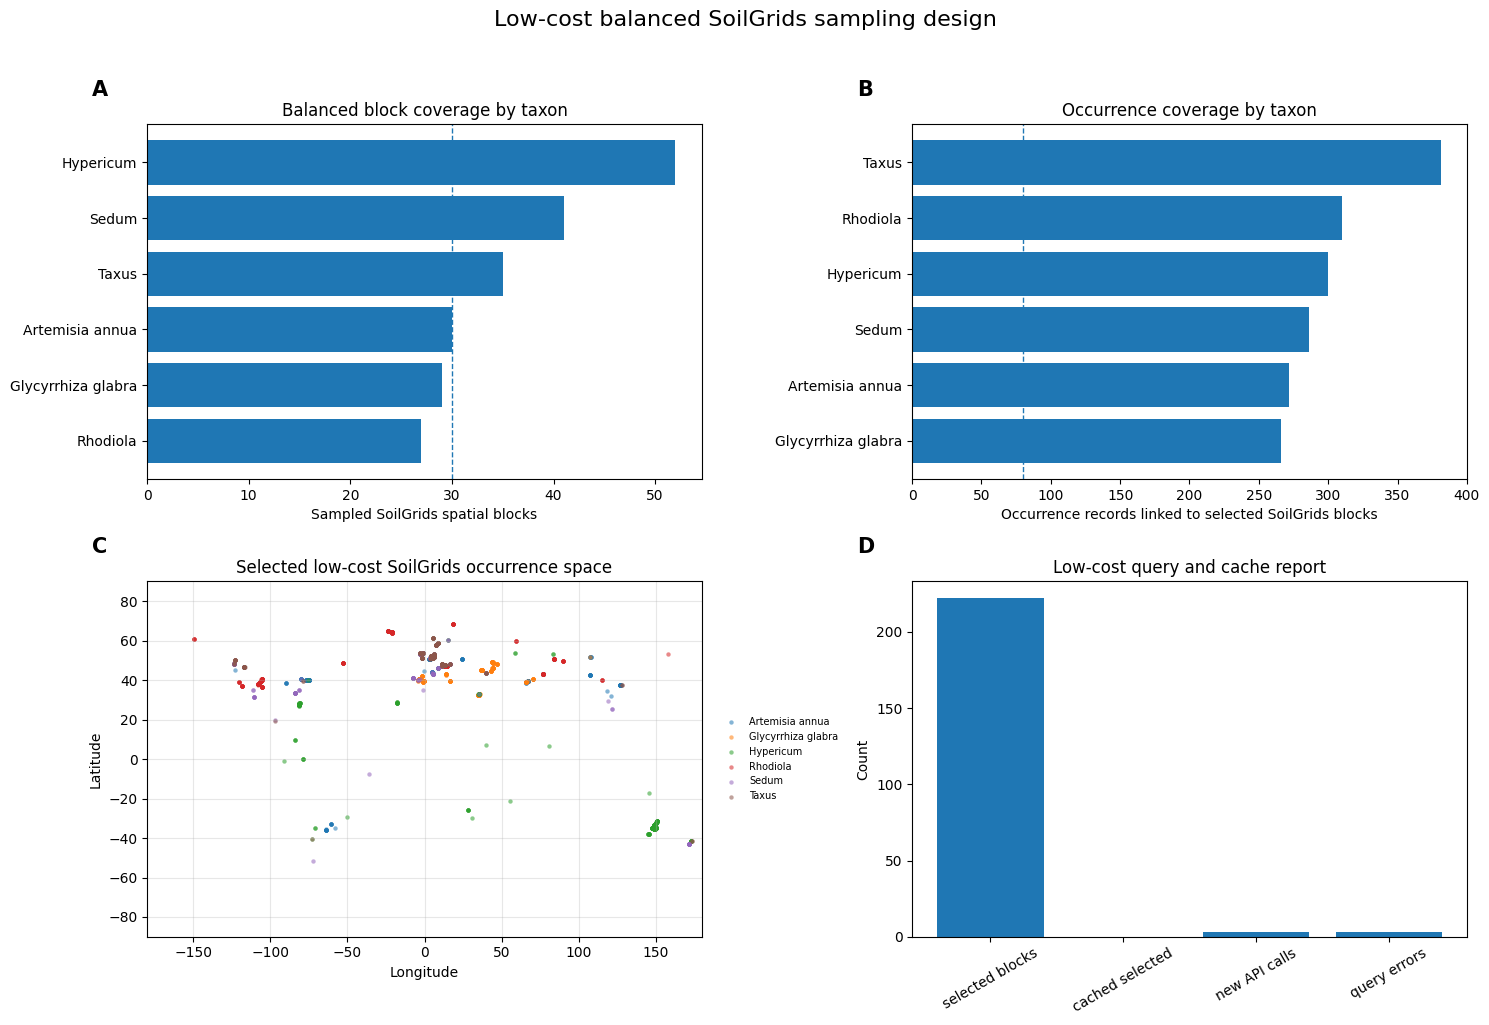

In [14]:
# ============================================================
# 13. Figure 1 — Low-cost sampling design and coverage
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.reshape(-1)

# A: selected blocks by taxon
ax = axes[0]
plot_df = coverage_by_taxon.sort_values("sampled_spatial_blocks_with_soil")
ax.barh(plot_df["input_taxon"], plot_df["sampled_spatial_blocks_with_soil"])
ax.axvline(CONFIG["min_soil_blocks_per_taxon_for_notebook2"], linestyle="--", linewidth=1)
ax.set_xlabel("Sampled SoilGrids spatial blocks")
ax.set_title("Balanced block coverage by taxon")
axes[0].text(-0.1, 1.08, "A", transform=axes[0].transAxes, fontsize=15, fontweight="bold")

# B: occurrence coverage
ax = axes[1]
plot_df = coverage_by_taxon.sort_values("sampled_occurrences_with_soil")
ax.barh(plot_df["input_taxon"], plot_df["sampled_occurrences_with_soil"])
ax.axvline(CONFIG["min_occurrences_covered_per_taxon_for_notebook2"], linestyle="--", linewidth=1)
ax.set_xlabel("Occurrence records linked to selected SoilGrids blocks")
ax.set_title("Occurrence coverage by taxon")
axes[1].text(-0.1, 1.08, "B", transform=axes[1].transAxes, fontsize=15, fontweight="bold")

# C: selected occurrence map
ax = axes[2]
for taxon, sub in occ_soil_df.groupby("input_taxon"):
    ax.scatter(
        pd.to_numeric(sub["decimal_longitude"], errors="coerce"),
        pd.to_numeric(sub["decimal_latitude"], errors="coerce"),
        s=10,
        alpha=0.55,
        label=taxon,
        linewidths=0,
    )
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.grid(True, alpha=0.3)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Selected low-cost SoilGrids occurrence space")
ax.legend(frameon=False, fontsize=7, loc="center left", bbox_to_anchor=(1.02, 0.5))
axes[2].text(-0.1, 1.08, "C", transform=axes[2].transAxes, fontsize=15, fontweight="bold")

# D: cache/API cost report
ax = axes[3]
cost_items = pd.Series({
    "selected blocks": len(point_df),
    "cached selected": int(point_df["already_cached"].sum()),
    "new API calls": int((~query_point_df["point_id"].apply(has_cached_soil)).sum()),
    "query errors": len(error_df),
})
ax.bar(cost_items.index, cost_items.values)
ax.tick_params(axis="x", rotation=30)
ax.set_ylabel("Count")
ax.set_title("Low-cost query and cache report")
axes[3].text(-0.1, 1.08, "D", transform=axes[3].transAxes, fontsize=15, fontweight="bold")

fig.suptitle("Low-cost balanced SoilGrids sampling design", fontsize=16, y=1.02)
fig.tight_layout()
save_figure(fig, "figure1_low_cost_soilgrids_sampling_design_v3")
plt.show()

Saved: /content/soilgrids_medicinal_value_dataset_v3_low_cost/figures/figure2_soilgrids_feature_completeness_profiles_v3.png


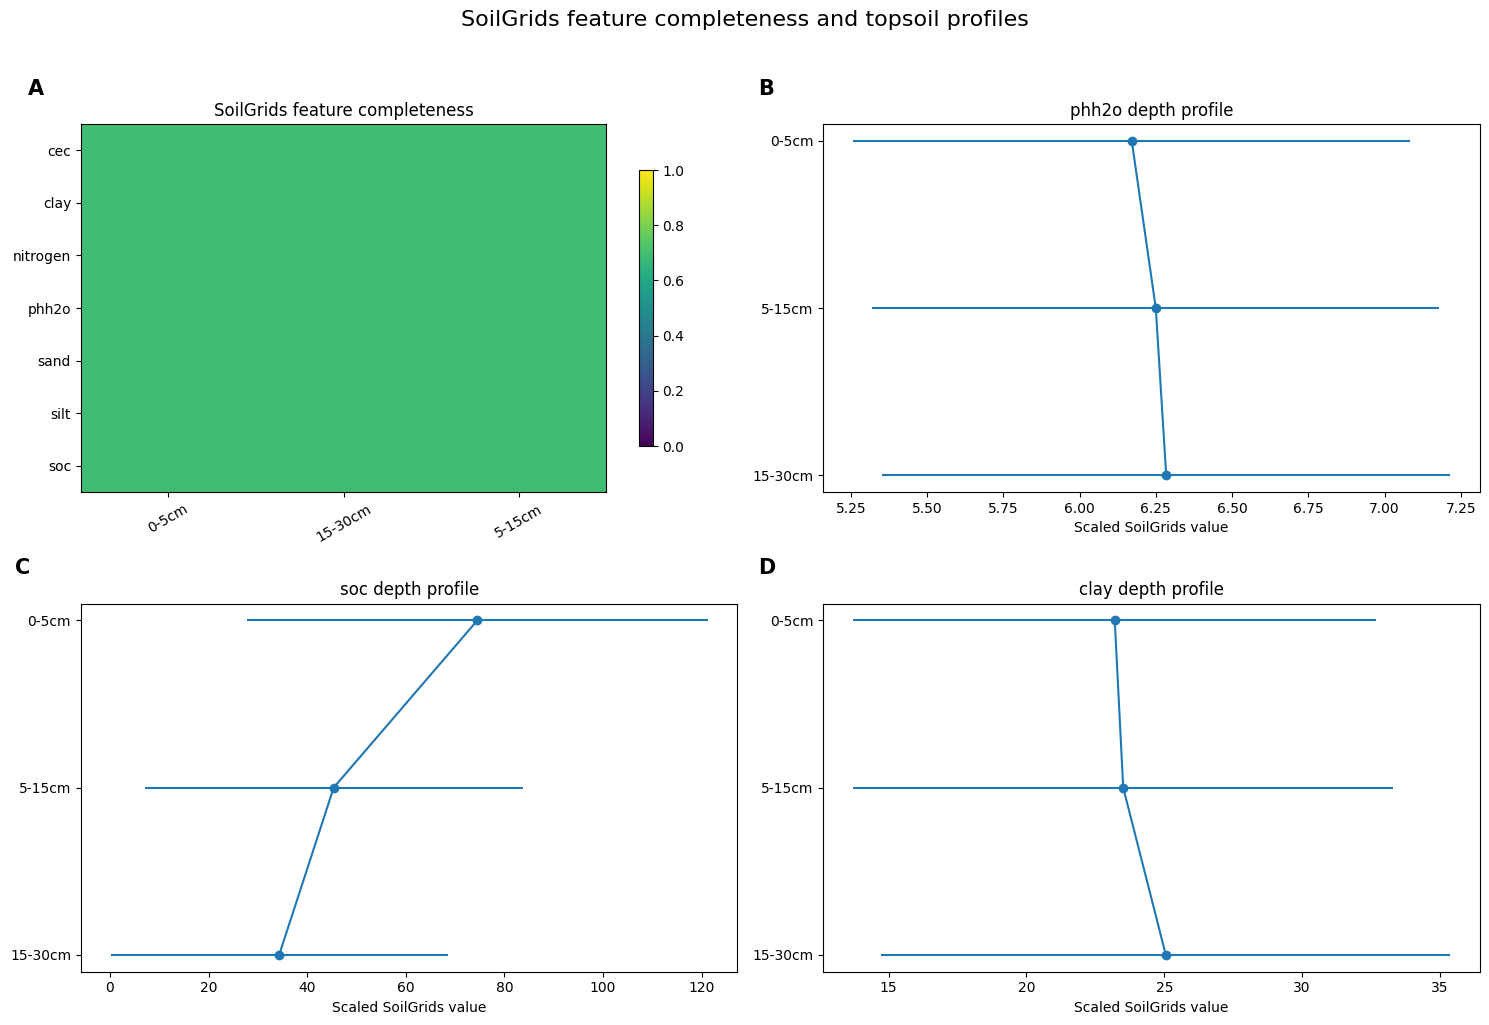

In [15]:
# ============================================================
# 14. Figure 2 — Soil feature completeness and topsoil profiles
# ============================================================

if not soilgrids_long_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.reshape(-1)

    # A: feature completeness by property/depth
    ax = axes[0]
    comp = (
        soilgrids_long_df
        .assign(has_value=lambda x: pd.to_numeric(x["scaled_value"], errors="coerce").notna())
        .groupby(["soil_property", "depth_label"])["has_value"]
        .mean()
        .reset_index()
    )
    pivot = comp.pivot(index="soil_property", columns="depth_label", values="has_value").fillna(0)
    im = ax.imshow(pivot.values, vmin=0, vmax=1, aspect="auto")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=30)
    ax.set_title("SoilGrids feature completeness")
    fig.colorbar(im, ax=ax, shrink=0.75)
    axes[0].text(-0.1, 1.08, "A", transform=axes[0].transAxes, fontsize=15, fontweight="bold")

    # B-D: selected property depth profiles
    profile_props = ["phh2o", "soc", "clay"]
    for ax, prop, label in zip(axes[1:], profile_props, ["B", "C", "D"]):
        sub = soilgrids_long_df[
            (soilgrids_long_df["soil_property"].eq(prop)) &
            (soilgrids_long_df["value_type"].eq("mean"))
        ].copy()
        sub["scaled_value"] = pd.to_numeric(sub["scaled_value"], errors="coerce")
        depth_order = CONFIG["soilgrids_depths"]
        prof = sub.groupby("depth_label")["scaled_value"].agg(["mean", "std"]).reindex(depth_order)
        ax.errorbar(prof["mean"], range(len(prof)), xerr=prof["std"], marker="o")
        ax.set_yticks(range(len(depth_order)))
        ax.set_yticklabels(depth_order)
        ax.invert_yaxis()
        ax.set_title(f"{prop} depth profile")
        ax.set_xlabel("Scaled SoilGrids value")
        ax.text(-0.1, 1.08, label, transform=ax.transAxes, fontsize=15, fontweight="bold")

    fig.suptitle("SoilGrids feature completeness and topsoil profiles", fontsize=16, y=1.02)
    fig.tight_layout()
    save_figure(fig, "figure2_soilgrids_feature_completeness_profiles_v3")
    plt.show()
else:
    print("No SoilGrids long table available for Figure 2.")

In [16]:
# ============================================================
# 15. Handoff manifest and QC report
# ============================================================

handoff_files = [
    {"file_role": "occurrence_soilgrids_features", "path": str(DIRS["derived"] / "occurrence_soilgrids_features.tsv"), "required_for_notebook2": True},
    {"file_role": "soilgrids_point_features_wide", "path": str(DIRS["soilgrids"] / "soilgrids_point_features_wide.tsv"), "required_for_notebook2": True},
    {"file_role": "soilgrids_point_features_long", "path": str(DIRS["soilgrids"] / "soilgrids_point_features_long.tsv"), "required_for_notebook2": True},
    {"file_role": "soilgrids_taxon_soil_summary", "path": str(DIRS["derived"] / "soilgrids_taxon_soil_summary.tsv"), "required_for_notebook2": True},
    {"file_role": "soilgrids_spatial_block_features", "path": str(DIRS["derived"] / "soilgrids_spatial_block_features.tsv"), "required_for_notebook2": True},
    {"file_role": "soilgrids_coverage_by_taxon_v3", "path": str(DIRS["derived"] / "soilgrids_coverage_by_taxon_v3.tsv"), "required_for_notebook2": True},
    {"file_role": "low_cost_sampling_plan", "path": str(DIRS["soilgrids"] / "soilgrids_low_cost_sampling_plan_by_taxon_v3.tsv"), "required_for_notebook2": True},
    {"file_role": "gbif_liberal_with_soil_sample_flag", "path": str(DIRS["derived"] / "gbif_liberal_with_soil_sample_flag_v3.tsv"), "required_for_notebook2": False},
    {"file_role": "target_taxa_config", "path": str(DIRS["metadata"] / "target_taxa_config.tsv"), "required_for_notebook2": True},
    {"file_role": "target_compounds_config", "path": str(DIRS["metadata"] / "target_compounds_config.tsv"), "required_for_notebook2": True},
]

handoff_df = pd.DataFrame(handoff_files)
handoff_df["exists_and_nonempty"] = handoff_df["path"].apply(lambda x: pathlib.Path(x).exists() and pathlib.Path(x).stat().st_size > 0)
handoff_df["ready_for_notebook2_all_taxa"] = all_taxa_ready
handoff_df["run_id"] = RUN_ID
handoff_df["created_utc"] = utc_now()

write_table(handoff_df, DIRS["derived"] / "soilgrids_notebook1_handoff_manifest")

qc_lines = [
    "# Notebook 1S v3 low-cost SoilGrids QC report",
    f"Run ID: {RUN_ID}",
    "",
    "## Design",
    "Sampling design: taxon-balanced, geographically stratified, fixed spatial-block quota.",
    f"Target SoilGrids blocks per taxon: {CONFIG['target_soil_blocks_per_taxon']}",
    f"Spatial block size degrees: {CONFIG['spatial_block_degrees']}",
    f"SoilGrids properties: {', '.join(CONFIG['soilgrids_properties'])}",
    f"SoilGrids depths: {', '.join(CONFIG['soilgrids_depths'])}",
    f"SoilGrids values: {', '.join(CONFIG['soilgrids_values'])}",
    "",
    "## Main counts",
    f"Raw GBIF records: {len(gbif_df)}",
    f"Liberal GBIF records: {len(gbif_liberal_df)}",
    f"Selected unique SoilGrids spatial blocks: {len(point_df)}",
    f"SoilGrids query points loaded/queried: {len(query_point_df)}",
    f"SoilGrids long rows: {len(soilgrids_long_df)}",
    f"SoilGrids wide rows: {len(soilgrids_wide_df)}",
    f"Selected occurrence-soil rows: {len(occ_soil_df)}",
    f"All taxa ready for Notebook 2S: {all_taxa_ready}",
    "",
    "## Taxon coverage",
]
qc_lines.extend(coverage_by_taxon.to_string(index=False).splitlines())
qc_lines.extend([
    "",
    "## Interpretation",
    "This is a low-cost stratified open-data soil-niche dataset.",
    "SoilGrids values are modelled soil-property predictions, not measured field soil samples.",
    "The dataset is suitable for Notebook 2S if all taxa pass the readiness gate.",
    "For Q1-level claims, frame results as open-data prioritization and soil-niche association, not causal metabolite accumulation.",
])

qc_path = DIRS["derived"] / "soilgrids_notebook1S_v3_qc_report.md"
qc_path.write_text("\n".join(qc_lines), encoding="utf-8")

display(handoff_df)
print(qc_path)

,file_role,path,required_for_notebook2,exists_and_nonempty,ready_for_notebook2_all_taxa,run_id,created_utc
0,occurrence_soilgrids_features,/content/soilgrids_medicinal_value_dataset_v3_...,True,True,True,20260515T044756Z,2026-05-15T05:01:38+00:00
1,soilgrids_point_features_wide,/content/soilgrids_medicinal_value_dataset_v3_...,True,True,True,20260515T044756Z,2026-05-15T05:01:38+00:00
2,soilgrids_point_features_long,/content/soilgrids_medicinal_value_dataset_v3_...,True,True,True,20260515T044756Z,2026-05-15T05:01:38+00:00
3,soilgrids_taxon_soil_summary,/content/soilgrids_medicinal_value_dataset_v3_...,True,True,True,20260515T044756Z,2026-05-15T05:01:38+00:00
4,soilgrids_spatial_block_features,/content/soilgrids_medicinal_value_dataset_v3_...,True,True,True,20260515T044756Z,2026-05-15T05:01:38+00:00
5,soilgrids_coverage_by_taxon_v3,/content/soilgrids_medicinal_value_dataset_v3_...,True,True,True,20260515T044756Z,2026-05-15T05:01:38+00:00
6,low_cost_sampling_plan,/content/soilgrids_medicinal_value_dataset_v3_...,True,True,True,20260515T044756Z,2026-05-15T05:01:38+00:00
7,gbif_liberal_with_soil_sample_flag,/content/soilgrids_medicinal_value_dataset_v3_...,False,True,True,20260515T044756Z,2026-05-15T05:01:38+00:00
8,target_taxa_config,/content/soilgrids_medicinal_value_dataset_v3_...,True,True,True,20260515T044756Z,2026-05-15T05:01:38+00:00
9,target_compounds_config,/content/soilgrids_medicinal_value_dataset_v3_...,True,True,True,20260515T044756Z,2026-05-15T05:01:38+00:00


/content/soilgrids_medicinal_value_dataset_v3_low_cost/derived/soilgrids_notebook1S_v3_qc_report.md


In [17]:
# ============================================================
# 16. Fast manifest without hashing API cache
# ============================================================

manifest_rows = []
skip_dirs = {"api_cache", "checkpoints"}

for path in PROJECT.rglob("*"):
    if not path.is_file():
        continue
    if any(part in skip_dirs for part in path.parts):
        continue
    try:
        manifest_rows.append({
            "path": str(path.relative_to(PROJECT)),
            "absolute_path": str(path),
            "bytes": path.stat().st_size,
            "modified_utc": dt.datetime.fromtimestamp(path.stat().st_mtime, tz=dt.timezone.utc).isoformat(timespec="seconds"),
            "run_id": RUN_ID,
        })
    except Exception as e:
        print("Skipping", path, e)

run_manifest_df = pd.DataFrame(manifest_rows).sort_values("path")
write_table(run_manifest_df, PROJECT / "run_file_manifest_fast")
run_manifest_df.head()

,path,absolute_path,bytes,modified_utc,run_id
47,derived/gbif_liberal_with_soil_sample_flag_v3....,/content/soilgrids_medicinal_value_dataset_v3_...,492854,2026-05-15T05:01:35+00:00,20260515T044756Z
38,derived/gbif_liberal_with_soil_sample_flag_v3.tsv,/content/soilgrids_medicinal_value_dataset_v3_...,3481313,2026-05-15T05:01:35+00:00,20260515T044756Z
41,derived/occurrence_soilgrids_features.parquet,/content/soilgrids_medicinal_value_dataset_v3_...,196512,2026-05-15T05:01:35+00:00,20260515T044756Z
35,derived/occurrence_soilgrids_features.tsv,/content/soilgrids_medicinal_value_dataset_v3_...,1098179,2026-05-15T05:01:35+00:00,20260515T044756Z
43,derived/soilgrids_coverage_by_taxon_v3.parquet,/content/soilgrids_medicinal_value_dataset_v3_...,6907,2026-05-15T05:01:35+00:00,20260515T044756Z


In [18]:
import shutil
from google.colab import files

# Zip the entire project directory
zip_filename = "soilgrids_medicinal_value_dataset_outputs"
shutil.make_archive(zip_filename, 'zip', PROJECT)

# Download the zip file
files.download(zip_filename + '.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. What to do if the readiness gate fails

Open:

`derived/soilgrids_coverage_by_taxon_v3.tsv`

If one taxon fails, do **not** run Notebook 2S yet. Instead:

1. Increase:
   ```python
   CONFIG["target_soil_blocks_per_taxon"] = 60
   ```

2. Rerun from:
   - `Build low-cost stratified balanced sampling design`
   - through the end.

The cache will prevent repeated API calls for already queried blocks.

If cost is extremely constrained, keep 40 blocks/taxon and frame the manuscript as:

> low-cost proof-of-concept open-data workflow

rather than:

> definitive global soil predictor of medicinal value